# Likes Data Report
## Madeline Griffiths - 09/21/2026

- Who or what is the source of your personal Instagram data? (you downloaded the data, but did you create it?)
  - The data is from my personal Instagram data but was compiled by Meta
- Why was this data created and what purposes can the data serve?
  - This data was created by Meta to track my habits on my account. This includes my habits on which posts I like, which advertisements I interact with, and other pieces of data that can be used by Meta to tailor my Instagram experience (what posts I see and what kind of ads I see).
- In what ways may this data be reliable?
  - The data can be reliable by giving me precise data about my habits and information. There is no misremembering.
- In what ways may this data be unreliable?
  - It does not show how long I was on a page or post. For instance, sometimes I have accidentally pressed ads I did not mean to. The data logs that as me interacting with the advertisement when it was accidental on my end.

In [1]:
import json
import pandas as pd

with open("liked_posts.json","r") as f:
    data = json.load(f)

print(len(data))
data[0]

901


{'timestamp': 1788799776,
 'media': [],
 'label_values': [{'label': 'URL',
   'value': 'https://www.instagram.com/p/DcweeoAiWKA/',
   'href': 'https://www.instagram.com/p/DcweeoAiWKA/'},
  {'label': 'Caption',
   'value': "Repost because instagram was only showing the second slide. Id not I'll just take the flop"},
  {'label': 'Title', 'value': ''},
  {'dict': [], 'title': 'Hashtags'},
  {'dict': [{'dict': [{'label': 'URL', 'value': 'https://linktr.ee/brujoari'},
      {'label': 'Name', 'value': 'Ari'},
      {'label': 'Username', 'value': '_spacechannel555_'}],
     'title': ''}],
   'title': 'Owner'},
  {'dict': [], 'title': 'Brand partner'}],
 'fbid': '18149868637522861'}

In [2]:
row = {}
row['timestamp'] = data[0]['timestamp']
row

{'timestamp': 1788799776}

In [3]:
for item in data[0]['label_values']:
    if "label" in item:
        row[item['label']]= item['value']
row

{'timestamp': 1788799776,
 'URL': 'https://www.instagram.com/p/DcweeoAiWKA/',
 'Caption': "Repost because instagram was only showing the second slide. Id not I'll just take the flop",
 'Title': ''}

In [4]:
for item in data[0]['label_values']:
    if "label" in item:
        row[item['label']]= item['value']
    elif item.get('title') == "Owner":
        owner_fields = item['dict'][0]['dict']
        for owner_item in owner_fields:
            row['Owner ' + owner_item['label']] = owner_item['value']
row

{'timestamp': 1788799776,
 'URL': 'https://www.instagram.com/p/DcweeoAiWKA/',
 'Caption': "Repost because instagram was only showing the second slide. Id not I'll just take the flop",
 'Title': '',
 'Owner URL': 'https://linktr.ee/brujoari',
 'Owner Name': 'Ari',
 'Owner Username': '_spacechannel555_'}

In [5]:
tidy_rows = []

for entry in data:
    row = {}
    row['timestamp'] = entry['timestamp']
    
    for item in entry['label_values']:
        if "label" in item:
            row[item['label']]= item['value']
        elif item.get('title') == "Owner":
            owner_fields = item['dict'][0]['dict']
            for owner_item in owner_fields:
                row['Owner ' + owner_item['label']] = owner_item['value']
    tidy_rows.append(row)
tidy_rows[:1]

[{'timestamp': 1788799776,
  'URL': 'https://www.instagram.com/p/DcweeoAiWKA/',
  'Caption': "Repost because instagram was only showing the second slide. Id not I'll just take the flop",
  'Title': '',
  'Owner URL': 'https://linktr.ee/brujoari',
  'Owner Name': 'Ari',
  'Owner Username': '_spacechannel555_'}]

In [6]:
likes_df = pd.DataFrame(tidy_rows)
likes_df.head(10)

,timestamp,URL,Caption,Title,Owner URL,Owner Name,Owner Username
0,1788799776,https://www.instagram.com/p/DcweeoAiWKA/,Repost because instagram was only showing the ...,,https://linktr.ee/brujoari,Ari,_spacechannel555_
1,1788737269,https://www.instagram.com/p/Dc8_B-8lXk_/,Bad Dads: Chapter 2 part 7\nReady or not here ...,,https://linktr.ee/SquiddyInks,Alyssa,squiddyinks
2,1788729799,https://www.instagram.com/reel/Dc2n1IjBh6q/,âplease do tellâ why does he sound so exci...,,,HYPEWHIP,hypewhip
3,1788729733,https://www.instagram.com/p/Dc2v9K2lbjl/,Doodling the Technical Difficulties gang in my...,,,Skyâs extended party bus,skysshed
4,1788725918,https://www.instagram.com/p/Dc35TV7jjDp/,"Penn National - September 3, 2026 - So glad I ...",,,ðð Sam Boyer,___samsham
5,1788725917,https://www.instagram.com/p/Dc35aYrju23/,"Penn National - September 3, 2026 - You can pr...",,,ðð Sam Boyer,___samsham
6,1788725911,https://www.instagram.com/p/Dc47vE9jhjo/,"Penn National - September 4, 2026 - Gonna go t...",,,ðð Sam Boyer,___samsham
7,1788725910,https://www.instagram.com/p/Dc7NDARDktF/,"Went to Timonium today with some friends, had ...",,,ðð Sam Boyer,___samsham
8,1788549643,https://www.instagram.com/p/Dc2fCbHFMvu/,Art dump + wips I never finished oopsies\n\n#a...,,,Coven,covenbyte
9,1788549635,https://www.instagram.com/p/Dcz14FrDX6qniGUqOg...,best night of my life with the love of my life...,,,cal,human.calipede


In [7]:
likes_df["DateTime"] = pd.to_datetime(likes_df["timestamp"],unit="s")
likes_df[['timestamp','DateTime']].head()
#likes_df.head()

,timestamp,DateTime
0,1788799776,2026-09-07 16:49:36
1,1788737269,2026-09-06 23:27:49
2,1788729799,2026-09-06 21:23:19
3,1788729733,2026-09-06 21:22:13
4,1788725918,2026-09-06 20:18:38


In [8]:
likes_df.shape

(901, 8)

In [9]:
likes_df['Owner Username'].isna().sum()

np.int64(0)

In [10]:
likes_df.dtypes

timestamp                 int64
URL                         str
Caption                     str
Title                       str
Owner URL                   str
Owner Name                  str
Owner Username              str
DateTime          datetime64[s]
dtype: object

In [11]:
likes_df.groupby("Owner Username")['DateTime'].count()

Owner Username
4billion_                       1
_.phopollo._                    7
___samsham                     17
_juicebox_draws                 1
_spacechannel555_              63
                               ..
yeehawyuri42                    1
ymkiken                         3
yogibo_versaillesresortfarm     1
zach_nesvacil                   2
zenthetreeman                   1
Name: DateTime, Length: 306, dtype: int64

In [12]:
likes_by_account = (
    likes_df.groupby("Owner Username")['DateTime']
    .count()
    .sort_values(ascending=False)
)
likes_by_account.head(10)

Owner Username
yaoibong.web          65
_spacechannel555_     63
no_refunds____        61
squiddyinks           58
skysshed              27
m_i00__               21
unico_uniuni          20
indoor_outdoor_kat    19
jackieirlreal         17
___samsham            17
Name: DateTime, dtype: int64

## Hypothesis: Majority (over 50%) of the advertisers using my activity or information have the word "inc." in their name.
- Theoretical elements
    - Independent variable: Whether an advertiser's name has "inc." in their name
    - Dependent variable: The presence of an advertiser in my "advertisers_using_your_activity_or_information.json" file
- Statistical elements
    - Population (all advertisers) and parameter (advertisers with "inc." in name)

The file I will be using is the "advertisers_using_your_activity_or_information.json" from my Instagram data. It will hopefully help me test my hypothesis by containing a full list of all of the advertisers that have my information.

In [17]:
with open("advertisers_using_your_activity_or_information.json","r") as f:
    data = json.load(f)

type(data)

dict

In [19]:
data.keys()
advertisers = data["label_values"][0]["vec"]
type(advertisers)

list

In [20]:
df = pd.DataFrame(data=advertisers)
df.head()

,value
0,Franchise Ramp
1,MPB
2,"InterContinental San Antonio Riverwalk, an IHG..."
3,ElevenLabs
4,Schneider Electric


In [21]:
df = df.rename(columns={"value": "advertiser_name"})
df.head()

,advertiser_name
0,Franchise Ramp
1,MPB
2,"InterContinental San Antonio Riverwalk, an IHG..."
3,ElevenLabs
4,Schneider Electric


In [22]:
df["advertiser_name"].nunique()

1582

In [35]:
inc_adsDf = df[df["advertiser_name"].str.contains("Inc.")]
inc_adsDf.head()

,advertiser_name
120,Time Inc. UK Commercial
145,"Bull Outdoor Products, Inc."
157,Reddit Inc.
243,Zynga Inc.
277,"Cinemark USA, Inc."


In [36]:
inc_adsDf.nunique()

advertiser_name    23
dtype: int64

The data follows neat data principles and displays the list of companies that are advertisers for me that have "Inc." in their names. It also gives me a number for the amount of companies that have "Inc." in their name (23 in total). This data can be used to prove or disprove my hypothesis when I compare it to the total number of advertisers I have in my "advertisers_using_your_activity_or_information.json" file.

I used the official MatPlotLib documentation on how to create pie charts in order to make the visualization:
https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

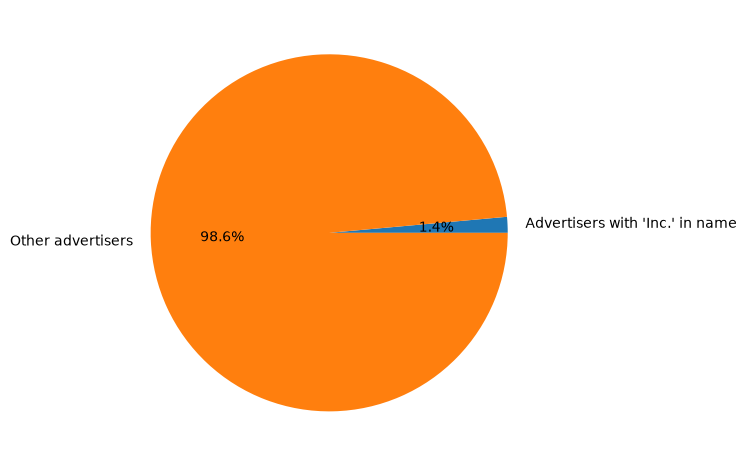

In [32]:
import matplotlib.pyplot as plt

#count of all advertisers and count of all advertisers with "inc." in name
all_advs = df["advertiser_name"].nunique()
inc_advs = inc_adsDf["advertiser_name"].nunique()

chart_labels = ["Advertisers with 'Inc.' in name", "Other advertisers"]
slice_vals = [inc_advs, all_advs]

fig, ax = plt.subplots()
ax.pie(slice_vals, labels=chart_labels, autopct='%1.1f%%')

plt.tight_layout()
plt.show()

Based on the data and the pie chart above, the majority of advertisers in my "advertisers_using_your_activity_or_information.json" file do not have "Inc." in their names. In fact, only 1.4% of advertisers in that file meet that criteria. A limitation of this data is that it does not include alternative names that a company might go under. For example, some advertisers in this data could have "Incorporated" in their namesor maybe they did not include the "Inc." in their names when registering for advertising through Meta. A possible way to fix this would be to include company aliases in the data when needed. Potential next steps I could start is visualizing the distribution of companies by type (when they include it in their title). For example, LLC, Corp., Co., Ltd., etc.